In [1]:
import os
import datetime
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import pandas as pd
from copy import deepcopy
import numpy as np
%matplotlib inline

plt.style.use('ggplot')

In [2]:
basedir = '.'
df = pd.read_csv(os.path.join(basedir, 'actividad2_6_0.csv'), index_col=0)
cheat_df = pd.read_csv(os.path.join(basedir, 'actividad2a_6_0.csv'), index_col=0)

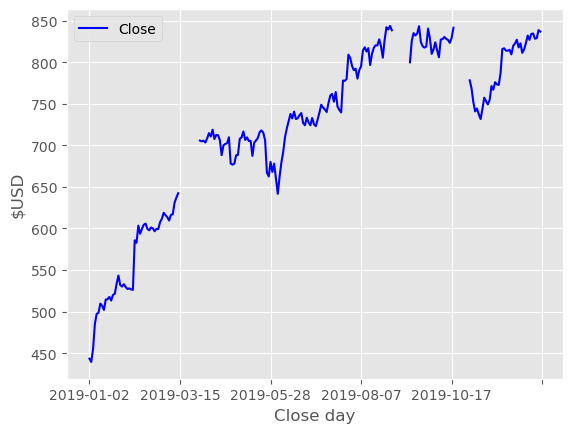

In [3]:
df.plot(kind='line', color='blue')

plt.xlabel('Close day')
plt.ylabel('$USD')
plt.show()

In [4]:
lags = list(range(1, 8, 1))

In [5]:
lagged_frame = pd.DataFrame(data=None, columns=['t'] + [f't-{d}' for d in lags])
lagged_frame['t'] = df.Close.values

In [6]:
lagged_frame.head()

,t,t-1,t-2,t-3,t-4,t-5,t-6,t-7
0,443.359985,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,439.450012,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,455.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,485.149994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,497.369995,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
for lag in lags:
    lagged_frame[f't-{lag}'] = lagged_frame['t'].shift(lag)

In [8]:
lagged_frame.head(8)

,t,t-1,t-2,t-3,t-4,t-5,t-6,t-7
0,443.359985,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,439.450012,443.359985,NaN,NaN,NaN,NaN,NaN,NaN
2,455.000000,439.450012,443.359985,NaN,NaN,NaN,NaN,NaN
3,485.149994,455.000000,439.450012,443.359985,NaN,NaN,NaN,NaN
4,497.369995,485.149994,455.000000,439.450012,443.359985,NaN,NaN,NaN
5,498.480011,497.369995,485.149994,455.000000,439.450012,443.359985,NaN,NaN
6,509.619995,498.480011,497.369995,485.149994,455.000000,439.450012,443.359985,NaN
7,506.950012,509.619995,498.480011,497.369995,485.149994,455.000000,439.450012,443.359985


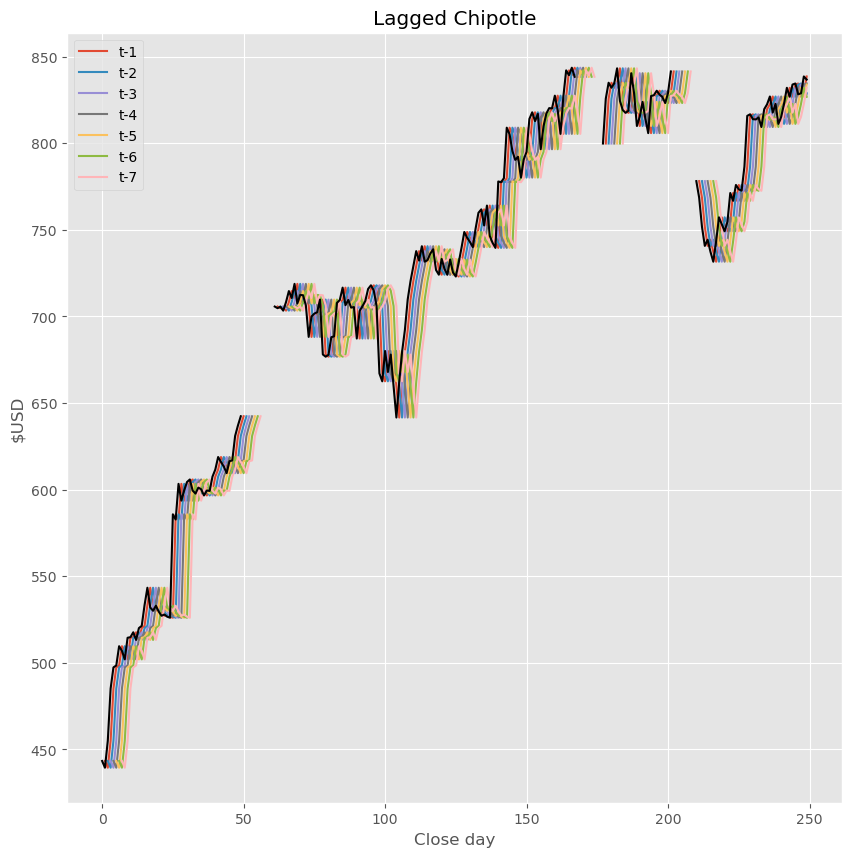

In [9]:
lag_names = [f't-{lag}' for lag in lags]
lagged_frame[lag_names].plot(figsize=(10, 10))

lagged_frame['t'].plot(figsize=(10,10), color='black')

plt.title('Lagged Chipotle')
plt.xlabel('Close day')
plt.ylabel('$USD')
plt.show()

In [10]:
lagged_copy = lagged_frame.copy()
lagged_copy2 = lagged_frame.copy()

lagged_copy.dropna(inplace=True)

In [11]:
modelo = LinearRegression()
response = ['t']
predictores = sorted(set(lagged_copy.columns).difference(response))

In [12]:
modelo.fit(lagged_copy[predictores], lagged_copy[response])

LinearRegression()

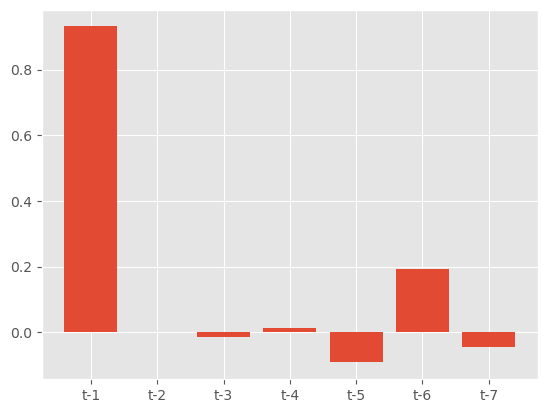

In [13]:
fig, ax = plt.subplots()

index = range(len(predictores))
ax.bar(index, modelo.coef_[0])

ax.set_xticks(index)
ax.set_xticklabels(predictores)
plt.show()

In [14]:
df_to_estimate = lagged_frame.loc[lagged_frame['t'].isnull()]
df_to_estimate

,t,t-1,t-2,t-3,t-4,t-5,t-6,t-7
50,NaN,642.390015,637.070007,630.989990,616.880005,616.440002,609.530029,613.409973
51,NaN,NaN,642.390015,637.070007,630.989990,616.880005,616.440002,609.530029
52,NaN,NaN,NaN,642.390015,637.070007,630.989990,616.880005,616.440002
53,NaN,NaN,NaN,NaN,642.390015,637.070007,630.989990,616.880005
54,NaN,NaN,NaN,NaN,NaN,642.390015,637.070007,630.989990
55,NaN,NaN,NaN,NaN,NaN,NaN,642.390015,637.070007
56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,642.390015
57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
index_datos_a_estimar = df_to_estimate.index.tolist()

In [16]:
estimaciones = []
primera_posicion = min(index_datos_a_estimar)

values_reshape = df_to_estimate.loc[primera_posicion, predictores].values.reshape(1, -1)


In [17]:
estimaciones.append(modelo.predict(values_reshape)[0][0])
estimaciones

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


[642.8071411875994]

In [18]:
lagged_copy2.loc[primera_posicion, 't'] = estimaciones[0]

In [19]:
lagged_copy2.loc[index_datos_a_estimar]

,t,t-1,t-2,t-3,t-4,t-5,t-6,t-7
50,642.807141,642.390015,637.070007,630.989990,616.880005,616.440002,609.530029,613.409973
51,NaN,NaN,642.390015,637.070007,630.989990,616.880005,616.440002,609.530029
52,NaN,NaN,NaN,642.390015,637.070007,630.989990,616.880005,616.440002
53,NaN,NaN,NaN,NaN,642.390015,637.070007,630.989990,616.880005
54,NaN,NaN,NaN,NaN,NaN,642.390015,637.070007,630.989990
55,NaN,NaN,NaN,NaN,NaN,NaN,642.390015,637.070007
56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,642.390015
57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
for lag in lags:
    lagged_copy2[f't-{lag}'] = lagged_copy2['t'].shift(lag)

In [21]:
for posicion, index in enumerate(index_datos_a_estimar[1::]):
    values_reshape = lagged_copy2.loc[index, predictores].values.reshape(1,-1)

    estimaciones.append(modelo.predict(values_reshape)[0][0])

    lagged_copy2.loc[index, 't'] = estimaciones[posicion + 1]

    for lag in lags:
        lagged_copy2[f't-{lag}'] = lagged_copy2['t'].shift(lag)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not ha

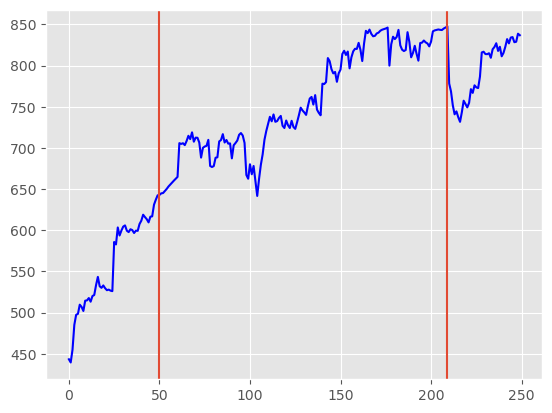

In [22]:
lagged_copy2['t'].plot(kind='line', color='blue')

plt.axvline(min(index_datos_a_estimar))
plt.axvline(max(index_datos_a_estimar))
plt.show()

In [23]:
reales = cheat_df.iloc[index_datos_a_estimar, 0].values

In [24]:
diferencias = reales - np.array(estimaciones)
diferencias

array([ -3.80714119,  10.99492489,  20.70039543,  18.06919953,
        20.31782936,  18.33902965,  21.23540622,  30.69151184,
        37.5835828 ,  39.93912492,  45.53091603,  -7.6367055 ,
         2.22741839,  -0.82116196,  -3.62337587,  -2.63094194,
       -55.50950168, -45.06056281, -39.50913964, -58.19984458,
         8.90684666, -12.10947175, -55.57737639, -44.99189711,
       -55.21516594, -62.27887593, -82.36841709, -71.87748249])

In [25]:
diffs_cuadrado = diferencias**2
diffs_cuadrado

array([1.44943240e+01, 1.20888373e+02, 4.28506371e+02, 3.26495972e+02,
       4.12814190e+02, 3.36320009e+02, 4.50942478e+02, 9.41968899e+02,
       1.41252570e+03, 1.59513370e+03, 2.07306431e+03, 5.83192710e+01,
       4.96139269e+00, 6.74306964e-01, 1.31288527e+01, 6.92185551e+00,
       3.08130478e+03, 2.03045432e+03, 1.56097212e+03, 3.38722191e+03,
       7.93319174e+01, 1.46639306e+02, 3.08884477e+03, 2.02427081e+03,
       3.04871455e+03, 3.87865839e+03, 6.78455613e+03, 5.16637249e+03])

In [26]:
promedio = np.mean(diffs_cuadrado)

In [27]:
rmse = np.sqrt(promedio)
rmse

38.94799714369179

In [28]:
from sklearn.metrics import mean_squared_error

In [29]:
mean_squared_error(reales, estimaciones, squared=False)

38.94799714369179

**¿Por qué el modelo de la actividad 1 tuvo un mejor ajuste?**
- porque había una delta menor entre los datos que rodeaban el hueco

**¿Por qué no solo droppear todas las filas que tengan al menos un dato nulo y evitamos problemas?**
- y tirar por la borda los pocos datos que de por sí tenemos? Si fuera un porcentaje más aceptable y nuestros datos fueran más no sería tan mala idea pero tenemos como 250 registros

**¿Por qué no hay problema con que usemos "datos del futuro" para la interpolación (datos posteriores al "hueco")?**
- en una serie de tiempo, los valores cercanos entre sí tienden a estar correlacionados. Así que utilizar datos tanto anteriores como posteriores al hueco permite una estimación más precisa. Además, no estamos como tal prediciendo datos, los estamos rellenando sin afectar lo que ya teníamos, que es distinto.